# pybalmorel for Post-Processing
This notebook provide examples on how to use pybalmorel for pre-processing, post-processing and for executing Balmorel scenarios. Check the following pages:
- [Home](../README.md)
- [Pre-Processing](PreProcessing.ipynb)
- [Execution](Execution.ipynb)

In [94]:
import sys
import gams
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import gdxpds

# Get the absolute path of the Pybalmorel folder
pybalmorel_path = os.path.abspath("/Users/maxfavrot/Balmorel/pybalmorel_MaxF")

# Set the correct path for GAMS
gams_path = "/Library/Frameworks/GAMS.framework/Versions/48/Resources"

# Add Pybalmorel to Python's module search path
if pybalmorel_path not in sys.path:
    sys.path.insert(0, pybalmorel_path)

# Now, you can import your modules
from src.pybalmorel import MainResults
from src.pybalmorel.utils import symbol_to_df

# Set environment variables
os.environ["PATH"] = gams_path + ":" + os.environ.get("PATH", "")
os.environ["DYLD_LIBRARY_PATH"] = gams_path + ":" + os.environ.get("DYLD_LIBRARY_PATH", "")



## Plotter class

In [95]:
class ThesisPlotter:
    def __init__(self,
                 style='whitegrid',
                 palette='Set2',
                 font_scale=1.2,
                 context='notebook',
                 figsize=(10, 6),
                 dpi=100):
        sns.set_theme(style=style, palette=palette, context=context)
        sns.set_context(context, font_scale=font_scale)
        self.figsize = figsize
        self.dpi = dpi
        self.palette = sns.color_palette(palette)

    def barplot(self, df, category_col, value_col, scenario_col,
                title="", unit="", ylabel=None, xlabel=None, legend_title="Scenario",
                save=False):
        """
        Create a barplot comparing scenarios across categories.

        Parameters:
        - df: DataFrame with the input data
        - category_col: column to be used on the x-axis (e.g., "Technology")
        - value_col: column with the values (e.g., "Value")
        - scenario_col: column with different scenarios (used as hue)
        - title: plot title
        - unit: unit displayed on y-axis
        - ylabel: custom y-axis label
        - xlabel: custom x-axis label
        - legend_title: title for the legend
        - save: if true, saves the figure
        """
        plt.figure(figsize=self.figsize, dpi=self.dpi)
        ax = sns.barplot(data=df,
                         x=category_col,
                         y=value_col,
                         hue=scenario_col,
                         palette=self.palette,
                         errorbar=None)

        ax.set_title(title, fontsize=14, weight='bold')
        ax.set_ylabel(ylabel if ylabel else f"{value_col} [{unit}]" if unit else value_col)
        ax.set_xlabel(xlabel if xlabel else category_col)
        ax.legend(title=legend_title)
        plt.xticks()
        plt.tight_layout()

        if save:
            plt.savefig("test.png", dpi=100)
        plt.show()

plotter = ThesisPlotter()


## Working with Outputs

This section presents examples of how to work with the outputs from Balmorel

### MainResults

The main output from Balmorel is MainResults.gdx, which may be loaded from one path (demanding different filenames, e.g., MainResults_SC1.gdx, MainResults_SC2.gdx, etc.) or several paths (which by default gives scenario names of SC1, SC2, ..., SCN format if no list of scenario_names are provided)

In [96]:
### 1.1.2 Loading several scenarios
res = MainResults(files=['MainResults_LowR_B.gdx', 'MainResults_LowR_HDISC.gdx', 'MainResults_LowR_excel.gdx'], paths='../master_thesis/main_results/MainResults', scenario_names=['SC1', 'SC2', 'SC3'])
res_a = MainResults(files=['all_endofmodel_LowR_B.gdx', 'all_endofmodel_LowR_HDISC.gdx', 'all_endofmodel_LowR_excel.gdx'], paths='../master_thesis/main_results/all_endofmodel', scenario_names=['SC1', 'SC2', 'SC3'])


/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_LowR_B.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_LowR_HDISC.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_LowR_excel.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/all_endofmodel/all_endofmodel_LowR_B.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/all_endofmodel/all_endofmodel_LowR_HDISC.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/all_endofmodel/all_endofmodel_LowR_excel.gdx


In [97]:
### 1.1.3 Plotting bar charts with an interactive gui
res.interactive_bar_chart()

Result type: balmorel


GridBox(children=(Dropdown(description='Table:', layout=Layout(width='80%'), options=('F_CONS_YCRA', 'F_CONS_Y…

Output()

Stack(children=(GridBox(children=(SelectMultiple(description='Scenario', index=(0,), layout=Layout(height='99%…

Output()

Output()

HBox()

Output()

Output()

Output()

# Sense check: Total costs of the system
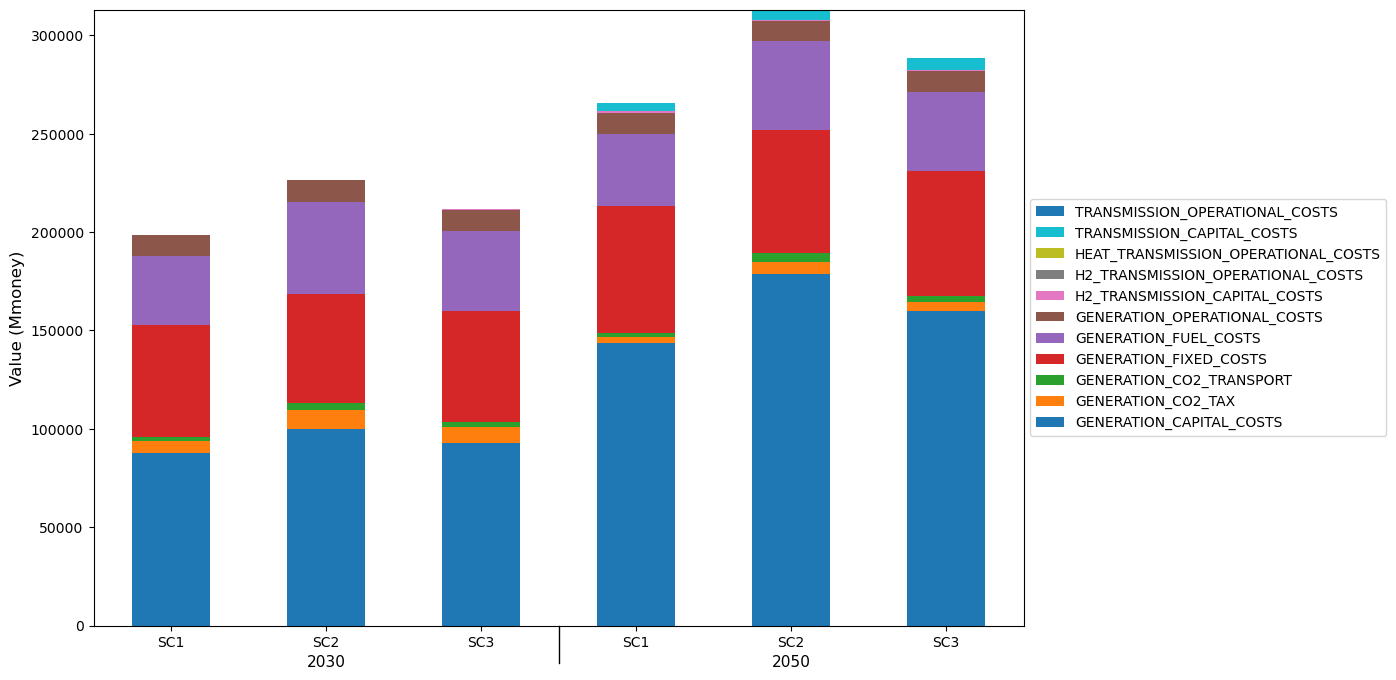

# GENERATION MIX
## Main Idea: There will be more renewable energy sources (RES) with a lower discount rate (DR)
Arguments:
- RES like wind and solar are Capital Expenditures (CAPEX)-intensive with low Operating Expenditures (OPEX), so most of the negative cashflows occur in the beginning in the project (with a high present value), and most of the positive cashflows (liked to revenues) occur later in time, so more subject to discounting. 
- A lower DR makes upfront investments more attractive, improving project economics for RES. 
- A higher DR penalizes long-term returns, making fossil plants with lower CAPEX and shorter payback periods more competitive.

As a result, higher DR favours gas/coal, while lower DR accelerates RES deployment.

"The most influential parameters for Renewable Energy Production is the discount rate" according to N. Moksnes & W. Usher in The relative importance of uncertain parameters and structural formulation for electricity systems planning in Kenya and Benin




In [98]:
# --- GENERAL FILTERS ---
Year = '2030'
Scenario = 'SC1'

res_fuels = ['SUN', 'WATER', 'WIND', 'WOOD', 'WOODCHIPS', 'WOODPELLETS', 'WOODWASTE']
commodity_fuels = ['ELECTRIC', 'HEAT', 'HYDROGEN']
dummy_fuels = ['DUMMY', 'IMPORT_H2', 'MUNIWASTE', 'WASTEHEAT']

Costs = [
    'GENERATION_FIXED_COSTS', 'GENERATION_OPERATIONAL_COSTS',
    'GENERATION_FUEL_COSTS', 'GENERATION_CAPITAL_COSTS',
    'GENERATION_CO2_TAX', 'GENERATION_CO2_TRANSPORT'
]
Capex = ['GENERATION_CAPITAL_COSTS', 'GENERATION_FIXED_COSTS']

In [99]:
prod_cap = res.get_result('G_CAP_YCRAF')
#prod_cap

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_51017/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.barplot(data=df,


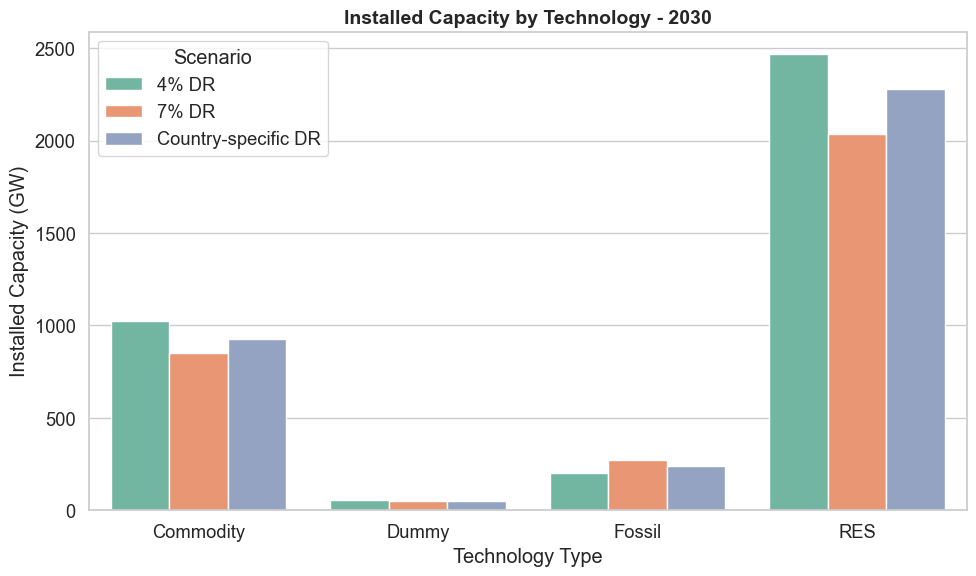

,Year,Scenario,Type,Value
0,2030,4% DR,Commodity,1025.691148
1,2030,4% DR,Dummy,53.005934
2,2030,4% DR,Fossil,201.477198
3,2030,4% DR,RES,2466.818672
4,2030,7% DR,Commodity,851.199689
5,2030,7% DR,Dummy,49.342891
6,2030,7% DR,Fossil,274.375407
7,2030,7% DR,RES,2035.378694
8,2030,Country-specific DR,Commodity,925.729622
9,2030,Country-specific DR,Dummy,51.712407


In [100]:
df = prod_cap.copy()

# --- FILTERS ---
df['Type'] = 'Fossil'  # Default
df.loc[df['Fuel'].isin(res_fuels), 'Type'] = 'RES'
df.loc[df['Fuel'].isin(commodity_fuels), 'Type'] = 'Commodity'
df.loc[df['Fuel'].isin(dummy_fuels), 'Type'] = 'Dummy'

# sum the values of unique combinaisons of year, scenario, type
df = df.groupby(['Year', 'Scenario', 'Type']).agg({'Value': 'sum'}).reset_index()

df = df[df['Year'] == Year]

# Filter out commodities and dummy fuels
#df = df[~df['Type'].isin(['Commodity', 'Dummy'])]

# --- RELABEL & CLEAN ---
df['Scenario'] = df['Scenario'].replace({
    'SC1': '4% DR',
    'SC2': '7% DR',
    'SC3': 'Country-specific DR'
})

# --- PLOT ---
plotter.barplot(df,
                category_col='Type',
                value_col='Value',
                scenario_col='Scenario',
                title="Installed Capacity by Technology - 2030",
                ylabel="Installed Capacity (GW)",
                xlabel="Technology Type",
                save=True)
df

### Reason 1: RES are CAPEX intensive and have lower OPEX

In [101]:
# --- GET THE DATA ---
g_cap = res.get_result('G_CAP_YCRAF')
g_prod = res.get_result('PRO_YCRAGFST')
eco_prod = res.get_result('ECO_G_YCRAG')

In [102]:
# --- FILTERS ---
g_cap = g_cap[(g_cap['Year'] == Year) & (g_cap['Scenario'] == Scenario)]
g_prod = g_prod[(g_prod['Year'] == Year) & (g_prod['Scenario'] == Scenario)]
eco_prod = eco_prod[(eco_prod['Y'] == Year) & (eco_prod['Scenario'] == Scenario)]

In [103]:
# --- GET PROD AND CAPACITY ---

# Group and rename g_cap
g_cap = (
    g_cap[['Generation', 'Value']]
    .groupby('Generation', as_index=False)
    .agg({'Value': 'sum'})
    .rename(columns={'Value': 'Capacity'})
)

# Group and rename g_prod
g_prod = (
    g_prod[['Generation', 'Value']]
    .groupby('Generation', as_index=False)
    .agg({'Value': 'sum'})
    .rename(columns={'Value': 'Production'})
)

In [104]:
# --- CLASSIFICATION & FILTERS ---

df = eco_prod.copy()

# Classify technology type
df['Type'] = 'Fossil'  # Default
df.loc[df['FFF'].isin(res_fuels), 'Type'] = 'RES'
df.loc[df['FFF'].isin(commodity_fuels), 'Type'] = 'Commodity'
df.loc[df['FFF'].isin(dummy_fuels), 'Type'] = 'Dummy'

# Filter only the relevant cost subcategories
df = df[df['SUBCATEGORY'].isin(Costs)]

# Label cost type
df['Cost'] = 'OPEX'  # Default
df.loc[df['SUBCATEGORY'].isin(Capex), 'Cost'] = 'CAPEX'

In [105]:
# --- AGGREGATION ---

# Sum cost values per tech type and cost category
df = df.groupby(['G', 'Type', 'Cost']).agg({'Value': 'sum'}).reset_index()
df.rename(columns={'Value': 'Total_costs'}, inplace=True) #EURm

# Merge with g_cap and g_prod
df = df.merge(g_cap, left_on='G', right_on='Generation', how='left')
df.drop(columns=['Generation'], inplace=True)
df = df.merge(g_prod, left_on='G', right_on='Generation', how='left')
df.drop(columns=['Generation'], inplace=True)

# Get the capacity and production of each type
df_merged = df.copy()
cap_prod = df_merged.groupby(['G', 'Type']).agg({'Capacity': 'max', 'Production': 'max'}).reset_index()
cap_prod = cap_prod.groupby('Type').agg({'Capacity': 'sum', 'Production': 'sum'}).reset_index()

# Group by 'Type' and 'Cost' and sum Value,
df_grouped = df.groupby(['Type', 'Cost']).agg({'Total_costs': 'sum',}).reset_index()
df_grouped = df_grouped.merge(cap_prod, on='Type', how='left')

In [106]:
# --- UNITS ---

# Calculate the value per MW and MWh
df_grouped['Cost_per_MW'] = df_grouped['Total_costs'] / df_grouped['Capacity'] / 1000 # EURm/MW
df_grouped['Cost_per_MWh'] = df_grouped['Total_costs'] / df_grouped['Production'] * 1000 # EUR/MWh
df_grouped['NCF_%'] = df_grouped['Production'] / df_grouped['Capacity'] / 8760 * 100 # NCF in %
# Round to 2 decimal places
df_grouped = df_grouped.round({
    'Cost_per_MW': 2,
    'Cost_per_MWh': 2,
    'NCF_%': 2,
    'Capacity': 2,
    'Production': 2,
    'Total_costs': 2
})

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_51017/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.barplot(data=df,


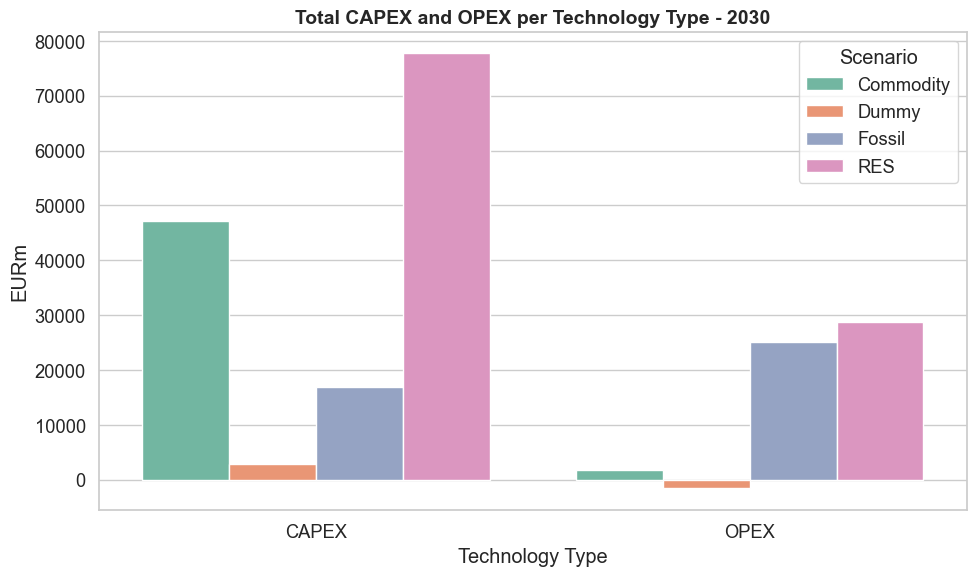

In [107]:
# --- PLOT ---

plotter.barplot(
    df_grouped,
    category_col='Cost',
    value_col='Total_costs',
    scenario_col='Type',
    title="Total CAPEX and OPEX per Technology Type - 2030",
    ylabel="EURm",  # Update if you know the actual unit
    xlabel="Technology Type",
    save=True
)
#df_grouped

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_51017/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.barplot(data=df,


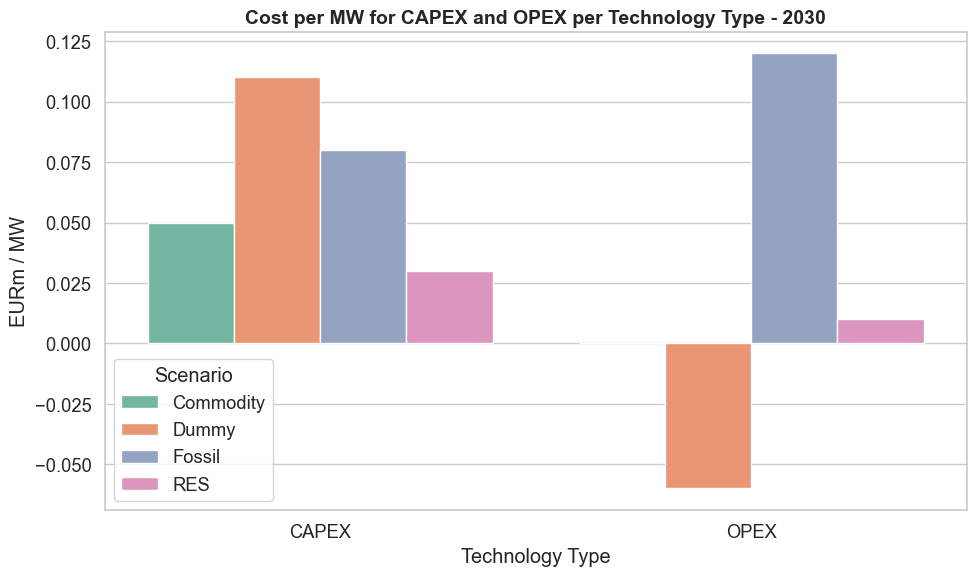

In [108]:
# --- PLOT ---

plotter.barplot(
    df_grouped,
    category_col='Cost',
    value_col='Cost_per_MW',
    scenario_col='Type',
    title="Cost per MW for CAPEX and OPEX per Technology Type - 2030",
    ylabel="EURm / MW",
    xlabel="Technology Type",
    save=True
)

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_51017/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.barplot(data=df,


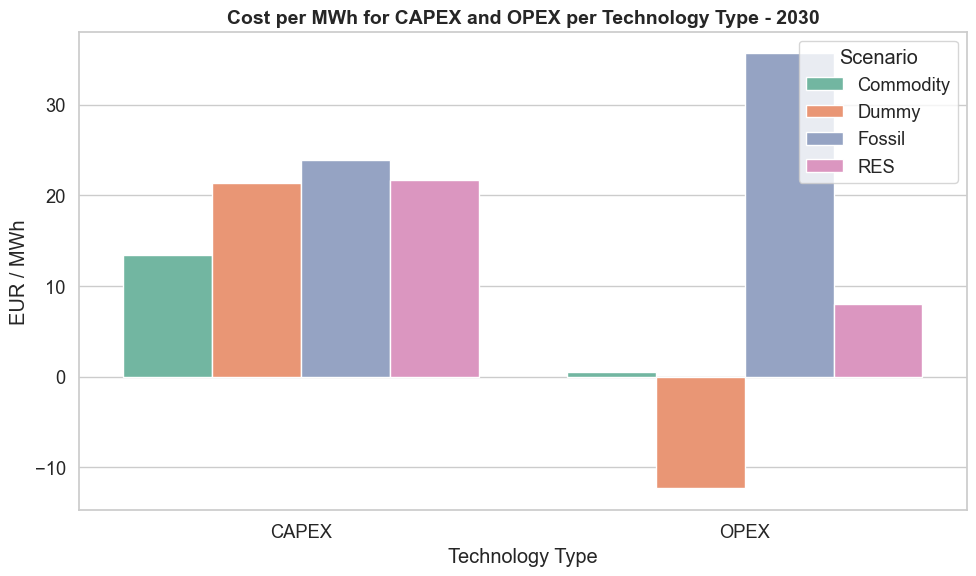

,Type,Cost,Total_costs,Capacity,Production,Cost_per_MW,Cost_per_MWh,NCF_%
0,Commodity,CAPEX,47163.14,1025.69,3508528.86,0.05,13.44,39.05
1,Commodity,OPEX,1757.20,1025.69,3508528.86,0.00,0.50,39.05
2,Dummy,CAPEX,2826.27,26.71,132070.29,0.11,21.40,56.44
3,Dummy,OPEX,-1630.46,26.71,132070.29,-0.06,-12.35,56.44
4,Fossil,CAPEX,16815.89,201.48,702398.24,0.08,23.94,39.80
5,Fossil,OPEX,25057.95,201.48,702398.24,0.12,35.67,39.80
6,RES,CAPEX,77725.91,2466.82,3588448.10,0.03,21.66,16.61
7,RES,OPEX,28652.12,2466.82,3588448.10,0.01,7.98,16.61


In [109]:
# --- PLOT ---

plotter.barplot(
    df_grouped,
    category_col='Cost',
    value_col='Cost_per_MWh',
    scenario_col='Type',
    title="Cost per MWh for CAPEX and OPEX per Technology Type - 2030",
    ylabel="EUR / MWh", 
    xlabel="Technology Type",
    save=True
)
df_grouped
